In [1]:
from itertools import islice

import torch

from torch import nn
from torch.nn import Linear
from PIL import Image
from torchvision.transforms import Compose, Resize, CenterCrop
from torchvision import transforms
# from torchvision.models import vgg11_bn, vgg11, resnet18

from zennit.attribution import Gradient, SmoothGrad
from zennit.core import Stabilizer
from zennit.composites import EpsilonGammaBox, EpsilonPlusFlat
# from zennit.composites import SpecialFirstLayerMapComposite, NameMapComposite
# from zennit.image import imgify, imsave
# from zennit.rules import Epsilon, ZPlus, ZBox, Norm, Pass, Flat
# from zennit.types import Convolution, Activation, AvgPool, Linear as AnyLinear
# from zennit.types import BatchNorm, MaxPool
# from zennit.torchvision import VGGCanonizer, ResNetCanonizer

from torchvision.models import ResNet18_Weights, VGG16_Weights

from matplotlib import pyplot as plt

from torch.nn import functional as F

In [2]:
from xaikd import models

In [3]:
model = models.get_trained_model("imagenet-vgg16-tv")

In [4]:
transform = VGG16_Weights.IMAGENET1K_V1.transforms()

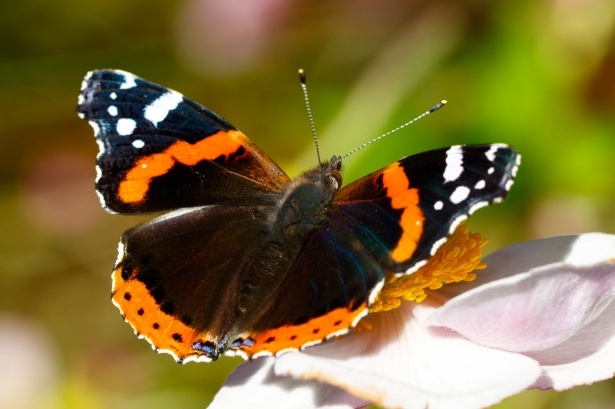

In [55]:
image = Image.open("./admiral.jpg")

image

In [56]:
def get_attributor(model):
    
    input_transform = transforms.Normalize(
        mean=transform.mean,
        std=transform.std
    )
    
    low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    composite = EpsilonGammaBox(low=low, high=high, canonizers=[])

    return Gradient(model=model, composite=composite)

get_attributor(model)

In [57]:
from matplotlib.colors import ListedColormap
import numpy as np

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    fontsize=None,
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)
    if total_score is None:
        percent = 100
        txt = r"$\sum_i R_i=%.2f$" % (sum_Ri)
    else:
        percent = (sum_Ri / total_score) * 100
        txt = r"$\sum_i R_i=%.4f$ (%3.1f%%)" % (sum_Ri, percent)

    plt.axis("on")
    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

    h = heatmap.shape[0]
    
    plt.title(f"{title}", fontsize=fontsize)
    if logit is not None:
        plt.xlabel(f"{txt}, logit={logit:.4f}", fontsize=fontsize)
    else:
        plt.xlabel(f"{txt}", fontsize=fontsize)

> output[321]=44.08


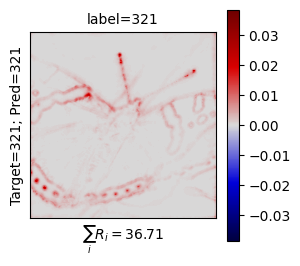

In [58]:
def viz(model, label, num_classes=1000):
        
    data = transform(image)[None]
    
    logit_mod = lambda logits: logits * F.one_hot(torch.Tensor([label]).long(), num_classes)

    # create the attributor, specifying model
    with get_attributor(model) as attributor:
        # compute the model output and attribution
        output, attribution = attributor(data, logit_mod)
        
    
    heatmap = attribution.numpy().sum(axis=1).squeeze()
    
    output = output.squeeze().detach().cpu().numpy()
    if num_classes < 1000:
        print("output:", output)
        
    print(f"> output[{label}]={output[label]:.4}")
    
    ypred = np.argmax(output)
        
    
    plt.figure(figsize=(3, 3))
    _heatmap(heatmap, title=f"label={label}")
    plt.ylabel(f"Target={label}; Pred={ypred}")

    plt.colorbar()
    
    
        
viz(model, 321)

> output[325]=28.18


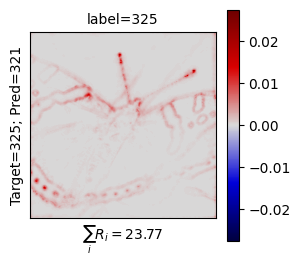

In [59]:
viz(model, 325)

In [60]:
from collections import OrderedDict
from copy import deepcopy
from torch import nn
import numpy as np 
import torch
from xaikd.utils.modules import merge_convKxK_and_conv1x1



def merging_model(model):
    
    features = []
          
    for layer_name in ["stem", "layer1", "layer2", "layer3", "layer4"]:
        layer = getattr(model, layer_name)
        for modul in layer.children():
            if hasattr(modul, "canonize"):
                features.append(modul.canonize())
            else:
                features.append(modul)
                
    merged_features = []
    
    arr_cls_modules = list(model.classifier.children())

    last_adapter = features[-1]

    
    features = features[:-1]
        
    for fix in range(len(features)):
        modul = features[fix]
        if fix < len(features)-2:
            next_modul = features[fix+1]
        else:
            next_modul = None
        
        if (isinstance(modul, nn.Conv2d) and modul.kernel_size[0] > 1) \
            and (isinstance(next_modul, nn.Conv2d) and next_modul.kernel_size[0] == 1):
            
            merged_features.append(merge_convKxK_and_conv1x1(modul, next_modul))
        elif isinstance(modul, nn.Conv2d) and modul.kernel_size[0] == 1:
            continue
        else:
            merged_features.append(modul)
            
            
    
            
    arr_cls_modules = list(model.classifier.children())
    

    merged_conv = merge_convKxK_and_conv1x1(last_adapter, arr_cls_modules[0])
    
                            
    return nn.Sequential(
        OrderedDict(
            [
                ("features", nn.Sequential(*merged_features)),
                ("classifier", nn.Sequential(merged_conv, *arr_cls_modules[1:]))
            ]
        )
    )

@torch.no_grad()
def get_canonized_model(num_classes=6):
    torch.manual_seed(1)
    x_train = torch.rand(5, 3, 224, 224)

    model = models.get_untrained_model("vggcustomimagenetdims-32-24-24-10", num_classes=num_classes)
    model(x_train)
    
    model.eval()
    
    canonized_model = merging_model(model)
    
    canonized_model.eval()
    
    x = torch.rand(5, 3, 224, 224)

    expected = model(x)
    actual = canonized_model(x)
    
    np.testing.assert_allclose(actual, expected, atol=1e-6)
    print(f"all testt passed! ")
    
    return canonized_model

canonized_model = get_canonized_model()
canonized_model

all testt passed! 


Sequential(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(32, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding

output: [ 0.0260628  -0.02675417 -0.0996839  -0.01355095 -0.0608567   0.16911933]
> output[0]=0.02606


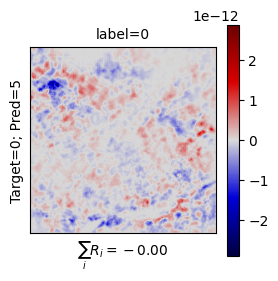

In [61]:
viz(canonized_model, 0, num_classes=6)

# wandb model

In [23]:
import wandb
run = wandb.init()

wandb: Currently logged in as: p16i. Use `wandb login --relogin` to force relogin


In [62]:
def load_trained_student_model(runid, num_classes=6):
    slug = f"p16i/kitchen-sink/{runid}"
    
    artifact = run.use_artifact(slug, type='model')
    artifact_dir = artifact.download()
    
    ckpt = torch.load(f"{artifact_dir}/model.ckpt", map_location=torch.device('cpu'))
        
    student = models.get_untrained_model("vggcustomimagenetdims-32-24-24-10", num_classes=num_classes)

    trainer_wrapper = nn.Sequential(OrderedDict([("student", student)]))
    trainer_wrapper.load_state_dict(ckpt["state_dict"])


    return student
    
load_trained_student_model("model-rpwdku89:best")

wandb:   1 of 1 files downloaded.  


Sequential(
  (stem): Sequential(
    (0): ConvBN(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ReLU()
    (2): ConvBN(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ConvBN(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ReLU()
    (2): ConvBN(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_runni

wandb:   1 of 1 files downloaded.  


output: [14.342794    2.0971816  -0.42819154 -5.468509   -2.6517136   0.9373971 ]
> output[0]=14.34


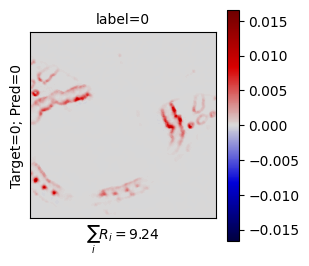

In [64]:
viz(
    # prca
    merging_model(load_trained_student_model("model-rpwdku89:best")).eval(), 
    label=0, 
    num_classes=6
)

wandb:   1 of 1 files downloaded.  


output: [16.472101   2.0514104 -1.4580587 -6.64387   -4.49975    3.0989873]
> output[0]=16.47


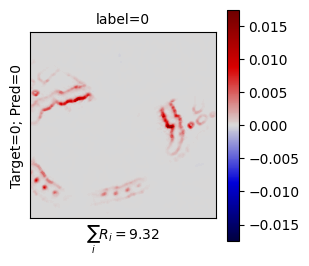

In [63]:
viz(
    # pca
    merging_model(load_trained_student_model("model-6nlssh52:best")).eval(), 
    label=0, 
    num_classes=6
)

wandb:   1 of 1 files downloaded.  


output: [15.357578   1.5702041 -1.7082926 -7.6149836 -4.5403934  1.7685759]
> output[0]=15.36


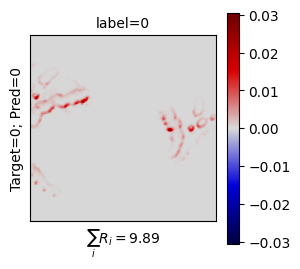

In [65]:
viz(
    # no KD
    merging_model(load_trained_student_model("model-ufs5j7gh:best")).eval(), 
    label=0, 
    num_classes=6
)